In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 94.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 73.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import dagshub
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as pp
import seaborn as sns
!pip install scorecardpy --quiet
import scorecardpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
from category_encoders.woe import WOEEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
dagshub.init(repo_owner='kgord23', repo_name='ML_hw_02_IEEE-CIS', mlflow=True)
mlflow.set_experiment("AdaBoost_Training")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=ba06a746-8c97-4b15-a1e7-e843a922a75d&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=940a7843c4c558aaab2342d7eec5b6da307b29e5bf8ab5fa97779b03631ae38c




Accessing as kgord23

Initialized MLflow to track repo "kgord23/ML_hw_02_IEEE-CIS"

Repository kgord23/ML_hw_02_IEEE-CIS initialized!

<Experiment: artifact_location='mlflow-artifacts:/ba977193cc6a48ca8f3cfcd11aef80b2', creation_time=1777966087600, experiment_id='3', last_update_time=1777966087600, lifecycle_stage='active', name='AdaBoost_Training', tags={}, trace_location=None, workspace='default'>

In [4]:
train_transaction= pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

In [5]:
train = train_transaction.merge(train_identity, on="TransactionID", how="left")

In [6]:
X=train.drop(columns='isFraud')
Y=train['isFraud']

X_train, X_val, Y_train, Y_val= train_test_split(X,Y, test_size=0.2, random_state=42)
X_train_raw = X_train.copy()
X_val_raw = X_val.copy()


<h1>Cleaning</h1>

In [7]:
class NULLDropperThreshold(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold=threshold
        
    def fit(self, X, y=None):
        missing_frac=X.isna().mean()
        self.cols_to_drop=missing_frac[missing_frac>self.threshold].index.tolist()
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])

In [8]:
missing_percent = X_train.isna().mean()* 100
missing_percent.sort_values(ascending=False)
missing_percent.describe()
missing_frac=X_train.isna().mean()
missing_frac = missing_frac[missing_frac > 0].sort_values(ascending=False)

In [9]:
threshold=0.80
cols_to_drop = missing_frac[missing_frac>threshold].index
X_train=X_train.drop(columns=cols_to_drop)
X_val=X_val.drop(columns=cols_to_drop)

In [10]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype=='object']
num_cols=[col for col in X_train.columns if X_train[col].dtype!='object']

In [8]:
class NULLFiller(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        num_cols=X.select_dtypes(exclude=['object']).columns
        cat_cols=X.select_dtypes(include=['object']).columns
        self.median=X[num_cols].median()
        self.mode=X[cat_cols].mode().iloc[0]
        return self

    def transform (self, X):
        X=X.copy()
        num_cols=X.select_dtypes(exclude=['object']).columns
        cat_cols=X.select_dtypes(include=['object']).columns
        X[num_cols]=X[num_cols].fillna(self.median)
        X[cat_cols]=X[cat_cols].fillna(self.mode)
        return X

In [11]:
median=X_train[num_cols].median()
X_train[num_cols]=X_train[num_cols].fillna(median)
X_val[num_cols]=X_val[num_cols].fillna(median)

mode=X_train[cat_cols].mode().iloc[0]
X_train[cat_cols]=X_train[cat_cols].fillna(mode)
X_val[cat_cols]=X_val[cat_cols].fillna(mode)

In [9]:
class VarianceThresholdDropper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01):
        self.threshold=threshold

    def fit(self, X, y=None):
        num_cols = X.select_dtypes(exclude=['object']).columns
        self.selected=VarianceThreshold(threshold=self.threshold)
        self.selected.fit(X[num_cols])
        self.low_var_cols=X[num_cols].columns[~self.selected.get_support()].tolist()
        return self
    def transform(self, X):
        return X.drop(columns=[c for c in self.low_var_cols if c in X.columns])

In [12]:
from sklearn.feature_selection import VarianceThreshold
selected = VarianceThreshold(threshold=0.01)
selected.fit(X_train[num_cols])
num_cols = X_train.select_dtypes(exclude=['object']).columns
low_var_cols=num_cols[~selected.get_support()].tolist()
print(f"low variance columns: {len(low_var_cols)}")
print(low_var_cols)
X_train=X_train.drop(columns=low_var_cols)
X_val=X_val.drop(columns=low_var_cols)

low variance columns: 24
['V1', 'V14', 'V27', 'V28', 'V41', 'V65', 'V68', 'V88', 'V89', 'V107', 'V108', 'V110', 'V111', 'V112', 'V113', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V240', 'V241', 'V305']


In [13]:
with mlflow.start_run(run_name="AdaBoost_Cleaning"):
    mlflow.log_param("null_threshold", 0.8)
    mlflow.log_param("filling_numeric", "median")
    mlflow.log_param("filling_cat", "mode")
    mlflow.log_param("variance_threshold", 0.01)
    mlflow.log_metric("low_variance_columns", len(low_var_cols))
    mlflow.log_metric("remaining_features", X_train.shape[1])
    mlflow.log_metric("remaining_rows", X_train.shape[0])

🏃 View run AdaBoost_Cleaning at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/3/runs/ef4524dd327f4edbb0dc23870cc0c32e
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/3


<h1>Feature Engineering</h1>

In [10]:
class NewColsAdd(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.email_freq=X['P_emaildomain'].value_counts()
        self.card_freqs={}
        for col in ['card1', 'card2', 'addr1']:
            self.card_freqs[col]=X[col].value_counts()
        X_tmp=X.copy()
        X_tmp['card_det']=X_tmp['card1'].astype(str) + '_' + X_tmp['card2'].astype(str) + '_' + X_tmp['addr1'].astype(str)
        self.card_det_freq=X_tmp['card_det'].value_counts()
        return self

    def transform(self, X):
        X=X.copy()
        X['TransactionAmt_log'] = np.log1p(X['TransactionAmt'])
        X['Transaction_hour'] = ((X['TransactionDT'] / 3600) % 24).astype(int)
        X['Transaction_day'] = ((X['TransactionDT'] / (3600 * 24)) % 7).astype(int)
        X['P_emaildomain_freq'] = X['P_emaildomain'].map(self.email_freq)
        X['card_det']=X['card1'].astype(str)+ '_' + X['card2'].astype(str)+'_'+X['addr1'].astype(str)

        for col in ['card1', 'card2', 'addr1']:
            X[col + '_freq'] = X[col].map(self.card_freqs[col])
        X['card_det_freq'] = X['card_det'].map(self.card_det_freq)
        return X

        

In [14]:
X_train['TransactionAmt_log']= np.log1p(X_train['TransactionAmt'])
X_val['TransactionAmt_log']=np.log1p(X_val['TransactionAmt'])

email_freq=X_train['P_emaildomain'].value_counts()
X_train['P_emaildomain_freq'] = X_train['P_emaildomain'].map(email_freq)
X_val['P_emaildomain_freq']=X_val['P_emaildomain'].map(email_freq)


X_train['Transaction_day'] = ((X_train['TransactionDT']/(3600*24))%7).astype(int)
X_train['Transaction_hour'] = ((X_train['TransactionDT']/3600)%24).astype(int)
X_val['Transaction_day'] = ((X_val['TransactionDT']/(3600*24))%7).astype(int)
X_val['Transaction_hour'] = ((X_val['TransactionDT']/3600)%24).astype(int)

X_train['card_det'] = X_train['card1'].astype(str)+'_' + X_train['card2'].astype(str)+'_' + X_train['addr1'].astype(str)
X_val['card_det'] = X_val['card1'].astype(str)+'_' + X_val['card2'].astype(str)+'_' + X_val['addr1'].astype(str)
for col in ['card1', 'card2', 'addr1', 'card_det']:
    card_freq=X_train[col].value_counts()
    X_train[col+'_freq']=X_train[col].map(card_freq)
    X_val[col+'_freq']=X_val[col].map(card_freq)

/tmp/ipykernel_57/4102201427.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['TransactionAmt_log']= np.log1p(X_train['TransactionAmt'])
/tmp/ipykernel_57/4102201427.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_val['TransactionAmt_log']=np.log1p(X_val['TransactionAmt'])
/tmp/ipykernel_57/4102201427.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) 

In [15]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"amount_of_cat_cols: {len(cat_cols)}")
print(f"cols: {cat_cols}")

amount_of_cat_cols: 27
cols: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'card_det']


In [16]:
class Encoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ohe_cols=['card4', 'card6', 'DeviceType', 'M1', 'M2', 'M3', 
                        'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'ProductCD']
        self.woe_cols=['P_emaildomain', 'R_emaildomain', 'id_12', 'id_15', 
                        'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 
                        'id_37', 'id_38', 'DeviceInfo', 'card_det']
    def fit(self, X, y=None):
        self.woe_cols_pr=[c for c in self.woe_cols if c in X.columns]
        self.ohe_cols_pr=[c for c in self.ohe_cols if c in X.columns]

        self.woe=WOEEncoder(cols=self.woe_cols_pr)
        self.woe.fit(X[self.woe_cols_pr],y)

        X_tmp = pd.get_dummies(X, columns=self.ohe_cols_pr)
        self.feature_names = X_tmp.columns 
        return self

    def transform(self, X):
        X=X.copy()
        for col in self.woe_cols_pr:
            if col not in X.columns:
                X[col] = 0
        X[self.woe_cols_pr]=self.woe.transform(X[self.woe_cols_pr])
        X=pd.get_dummies(X, columns=self.ohe_cols_pr)
        X = X.reindex(columns=self.feature_names, fill_value=0)
        X=X.fillna(0)
        return X
        

In [16]:
from category_encoders import WOEEncoder
ohe_cols = ['card4', 'card6', 'DeviceType', 'M1', 'M2', 'M3', 
            'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'ProductCD']

woe_cols = ['P_emaildomain', 'R_emaildomain', 'id_12', 'id_15', 
            'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 
            'id_37', 'id_38', 'DeviceInfo', 'card_det']

woe=WOEEncoder(cols=woe_cols)
X_train[woe_cols]=woe.fit_transform(X_train[woe_cols], Y_train)
X_val[woe_cols]=woe.transform(X_val[woe_cols])
print(f"after WOE : {X_train.shape[1]}")


X_train=pd.get_dummies(X_train, columns=ohe_cols)
X_val = pd.get_dummies(X_val, columns = ohe_cols)
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
print(f"afte OHE: {X_train.shape[1]}")

after WOE : 344
afte OHE: 365


In [23]:
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

In [17]:
with mlflow.start_run(run_name="AdaBoost_Feature_Engineering"):
    mlflow.log_metric("total_features", X_train.shape[1])
    mlflow.log_param("ohe_cols", ", ".join(ohe_cols))
    mlflow.log_param("woe_cols", ", ".join(woe_cols))

🏃 View run AdaBoost_Feature_Engineering at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/3/runs/49fef7febc684d2c9e718abe25f7a64f
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/3


<h1>Feature Selection</h1>

In [12]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.85):
        self.threshold=threshold
    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()
        corr_with_target = X.copy()
        corr_with_target['isFraud'] = y.values
        corr_with_target = corr_with_target.corr()['isFraud'].drop('isFraud')
        self.to_drop=set()
        for i in range (len(corr_matrix.columns)):
            for j in range(i +1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i,j])>  self.threshold:
                    col_i = corr_matrix.columns[i]
                    col_j = corr_matrix.columns[j]
                    if abs (corr_with_target[col_i])<abs(corr_with_target[col_j]):
                        self.to_drop.add(col_i)
                    else:
                        self.to_drop.add(col_j)
        return self
        

    def transform(self, X):
        return X.drop(columns=[c for c in self.to_drop if c in X.columns])


    

In [13]:
corr_matrix = X_train.corr().abs()
corr_with_target = X_train.copy()
corr_with_target['isFraud'] = Y_train.values
corr_with_target = corr_with_target.corr()['isFraud'].drop('isFraud')
threshold=0.85
to_drop=set()
for i in range (len(corr_matrix.columns)):
    for j in range(i +1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j])>threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            if abs (corr_with_target[col_i])<abs(corr_with_target[col_j]):
                to_drop.add(col_i)
            else:
                to_drop.add(col_j)
print(f"to_delete: {len(to_drop)}")
print(to_drop)

X_train = X_train.drop(columns=list(to_drop))
X_val=X_val.drop(columns=list(to_drop))
print(f"left cols: {X_train.shape[1]}")

ValueError: could not convert string to float: 'W'

In [19]:
with mlflow.start_run(run_name="AdaBoost_Selection"):
    mlflow.log_param("corr_threshold", 0.85)
    mlflow.log_metric("left columns",X_train.shape[1])

🏃 View run AdaBoost_Selection at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/3/runs/4529f9e1e4f341e1ac1aea6d03b616e1
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/3


<h1>Training</h1>

In [52]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=Y_train)
ada=AdaBoostClassifier(n_estimators=300,
                       learning_rate=0.6,
                       random_state=42)

ada.fit(X_train, Y_train, sample_weight=sample_weights)
Y_pred_proba_train=ada.predict_proba(X_train)[:,1]
Y_pred_proba_val=ada.predict_proba(X_val)[:,1]
Y_pred_val = ada.predict(X_val)

roc_auc_train=roc_auc_score(Y_train, Y_pred_proba_train)
roc_auc_val=roc_auc_score(Y_val, Y_pred_proba_val)
overfitting=roc_auc_train - roc_auc_val
print(f"Train ROC-AUC:      {roc_auc_train:.4f}")
print(f"Validation ROC-AUC: {roc_auc_val:.4f}")
print(f"diff:            {roc_auc_train - roc_auc_val:.4f}")
print(classification_report(Y_val, Y_pred_val))
                            

Train ROC-AUC:      0.9294
Validation ROC-AUC: 0.9125
diff:            0.0169
              precision    recall  f1-score   support

           0       0.99      0.89      0.94    113866
           1       0.21      0.77      0.33      4242

    accuracy                           0.89    118108
   macro avg       0.60      0.83      0.63    118108
weighted avg       0.96      0.89      0.92    118108



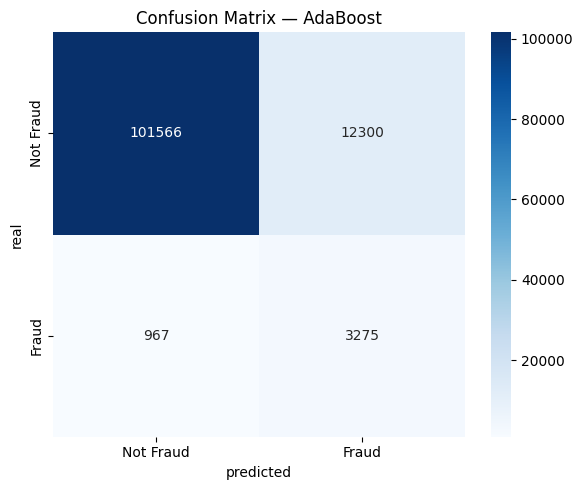

In [54]:
cm = confusion_matrix(Y_val, Y_pred_val)
tn, fp, fn, tp = cm.ravel()
pp.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
pp.title('Confusion Matrix — AdaBoost')
pp.ylabel('real')
pp.xlabel('predicted')
pp.tight_layout()
pp.savefig('ada_confusion_matrix.png')
pp.show()

In [55]:
with mlflow.start_run(run_name="AdaBoost_Training"):
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.6)
    mlflow.log_param("sample_weight", sample_weights)
    mlflow.log_metric("roc_auc_train", roc_auc_train)
    mlflow.log_metric("roc_auc_val", roc_auc_val)
    mlflow.log_metric("precision", precision_score(Y_val, Y_pred_val))
    mlflow.log_metric("recall", recall_score(Y_val, Y_pred_val))
    mlflow.log_metric("f1", f1_score(Y_val, Y_pred_val))
    mlflow.log_metric("true_negative", tn)   
    mlflow.log_metric("false_positive", fp)  
    mlflow.log_metric("false_negative", fn)  
    mlflow.log_metric("true_positive", tp)
    mlflow.log_artifact("ada_confusion_matrix.png")

🏃 View run AdaBoost_Training at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/3/runs/cbb61cb798304eb99f6cc1b133b2464c
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/3


In [17]:
full_pipeline=Pipeline([
    ('null_dropper', NULLDropperThreshold(threshold=0.80)),
    ('filler', NULLFiller()),
    ('new_cols_add',NewColsAdd()),
    ('encoder', Encoder()),
    ('correlation', CorrelationFilter(threshold=0.85)),
    ('model', AdaBoostClassifier(n_estimators=300,
                       learning_rate=0.6,
                       random_state=42))             
])

In [18]:
sample_weights = compute_sample_weight(class_weight='balanced', y=Y_train)
full_pipeline.fit(X_train_raw, Y_train, model__sample_weight=sample_weights)
Y_pred_proba_train = full_pipeline.predict_proba(X_train_raw)[:, 1]
Y_pred_proba_val = full_pipeline.predict_proba(X_val_raw)[:, 1]
Y_pred_val = full_pipeline.predict(X_val_raw)

roc_auc_train = roc_auc_score(Y_train, Y_pred_proba_train)
roc_auc_val = roc_auc_score(Y_val, Y_pred_proba_val)
overfitting=roc_auc_train - roc_auc_val
print(f"Train ROC-AUC:      {roc_auc_train:.4f}")
print(f"Validation ROC-AUC: {roc_auc_val:.4f}")
print(f"diff:            {roc_auc_train - roc_auc_val:.4f}")
print(classification_report(Y_val, Y_pred_val))

Train ROC-AUC:      0.9294
Validation ROC-AUC: 0.9125
diff:            0.0169
              precision    recall  f1-score   support

           0       0.99      0.89      0.94    113866
           1       0.21      0.77      0.33      4242

    accuracy                           0.89    118108
   macro avg       0.60      0.83      0.63    118108
weighted avg       0.96      0.89      0.92    118108



In [19]:
with mlflow.start_run(run_name="AdaBoost_Pipeline_Final"):
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.6)
    mlflow.log_param("sample_weight", "balanced")
    mlflow.log_metric("roc_auc_train", roc_auc_train)
    mlflow.log_metric("roc_auc_val", roc_auc_val)
    mlflow.log_metric("precision", precision_score(Y_val, Y_pred_val))
    mlflow.log_metric("recall", recall_score(Y_val, Y_pred_val))
    mlflow.log_metric("f1", f1_score(Y_val, Y_pred_val))
    tn, fp, fn, tp = confusion_matrix(Y_val, Y_pred_val).ravel()
    mlflow.log_metric("true_positive", tp)
    mlflow.log_metric("false_negative", fn)
    mlflow.sklearn.log_model(full_pipeline, "AdaBoost_pipeline")
    

2026/05/05 18:39:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 18:39:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run AdaBoost_Pipeline_Final at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/3/runs/bcdd447f57f44a9cbd412318bee58e86
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/3
